# Cleaning the dataset with missing and inconsistent values

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/StressLevelDataset_dirty.csv")
df.head(10)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,Good,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,High
1,6.0,26.0,0,8.0,1,2.0,Average,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,Low
2,5.0,25.0,NaN,6.0,1,2.0,Average,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,Low
3,12.0,23.0,1,10.0,3,1.0,Poor,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,Medium
4,19.0,15.0,1,27.0,5,NaN,Poor,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,High
5,3.0,26.0,0,8.0,1,NaN,Average,NaN,2,3,...,5,5.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
7,8.0,28.0,0,4.0,1,2.0,Average,2.0,1,3,...,5,5.0,2,5.0,NaN,3.0,2.0,2.0,1.0,Low
8,12.0,NaN,0,11.0,3,1.0,Poor,2.0,2,3,...,3,3.0,3,2.0,3.0,2.0,2.0,2.0,3.0,Low
9,20.0,14.0,1,NaN,5,NaN,Poor,5.0,4,2,...,2,2.0,4,2.0,NaN,1.0,5.0,NaN,5.0,High


## Checking out the stats for the dataset

In [3]:
df.shape

(1118, 21)

In [4]:
df.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1020 non-null   object 
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   object 
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  stu

In [6]:
df.describe()

,anxiety_level,self_esteem,depression,headache,blood_pressure,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1039.000000,1049.000000,1063.000000,1118.000000,1008.000000,1051.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1052.000000,1061.000000,995.000000,1039.000000,1017.000000,1027.000000
mean,11.887392,17.843661,12.921919,2.511628,2.177579,2.764986,2.649374,2.516995,2.727191,2.771914,2.769678,2.626118,2.649240,2.641847,1.887437,2.719923,2.751229,2.605648
std,8.603211,9.413546,8.317868,1.407026,0.875130,1.406431,1.322810,1.115199,1.401430,1.428962,1.402595,1.314378,1.379326,1.517167,1.040137,1.430300,1.404458,1.518337
min,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,7.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,12.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,17.000000,26.000000,19.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,92.000000,99.000000,59.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


In [7]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history            98
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                    90
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

### As we can see, we can't really drop the rows with NAs as it would significantly reduce the size of the dataset

In [8]:
df.dropna(inplace=False)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
18,18.0,10.0,1,23.0,3,3.0,Poor,5.0,5,1,...,2,2.0,4,1.0,4.0,1.0,4.0,4.0,4.0,High
22,7.0,25.0,0,0.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,5.0,1.0,3.0,1.0,1.0,1.0,Low
25,13.0,24.0,1,10.0,2,1.0,Poor,4.0,2,2,...,2,2.0,3,3.0,3.0,2.0,2.0,2.0,3.0,Medium
27,21.0,28.0,0,20.0,0,3.0,Poor,0.0,5,4,...,4,2.0,4,2.0,0.0,0.0,5.0,0.0,5.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,16.0,15.0,0,14.0,4,3.0,Average,5.0,1,2,...,5,3.0,1,1.0,1.0,1.0,5.0,2.0,2.0,High
1100,7.0,27.0,0,7.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
1104,21.0,1.0,1,17.0,3,3.0,Poor,4.0,5,1,...,1,1.0,4,2.0,5.0,1.0,5.0,5.0,5.0,High
1107,8.0,25.0,0,5.0,1,2.0,Average,1.0,2,4,...,4,4.0,1,4.0,1.0,3.0,1.0,2.0,1.0,Low


In [9]:
# df['stress_level'].value_counts()
df['sleep_quality'].value_counts()

sleep_quality
Poor       667
Average    341
Good        20
Name: count, dtype: int64

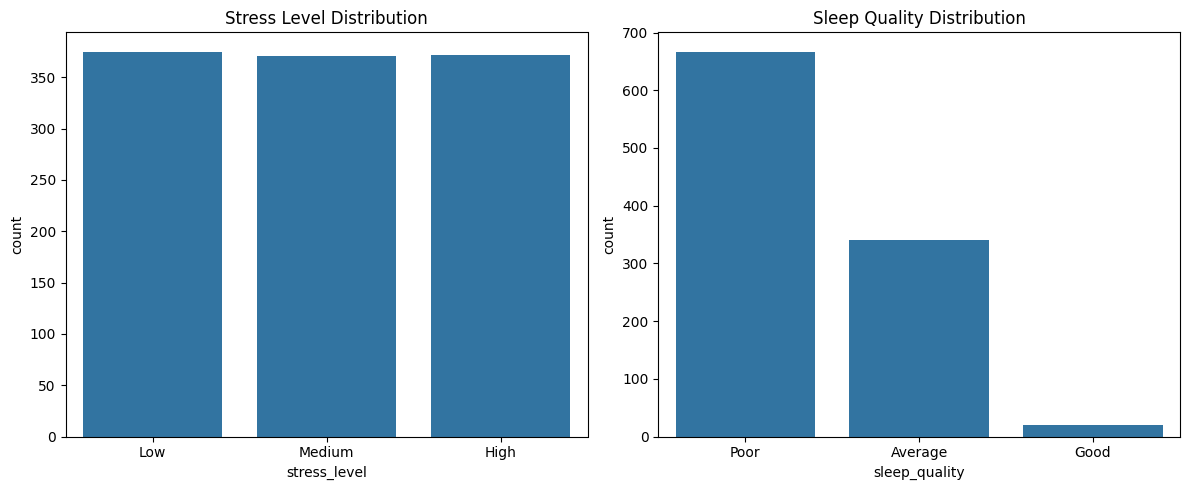

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='stress_level', data=df, order=['Low','Medium','High'])
plt.title("Stress Level Distribution")

plt.subplot(1,2,2)
sns.countplot(x='sleep_quality', data=df, order=['Poor','Average','Good'])
plt.title("Sleep Quality Distribution")

plt.tight_layout()
plt.show()

#### As we can observe from the above CountPlot of Stress_Level Column, all the stress levels are almost evenly distributed across Low, Medium, and High categories, indicating a balanced dataset without class imbalance. In Sleep Quality column analysis, it comes thats a majority of students report poor sleep quality, while very few report good sleep, indicating an overall decline in sleep patterns among students

## Checking co-relation between both categorical columns (Stress_level and Sleep_Quality)

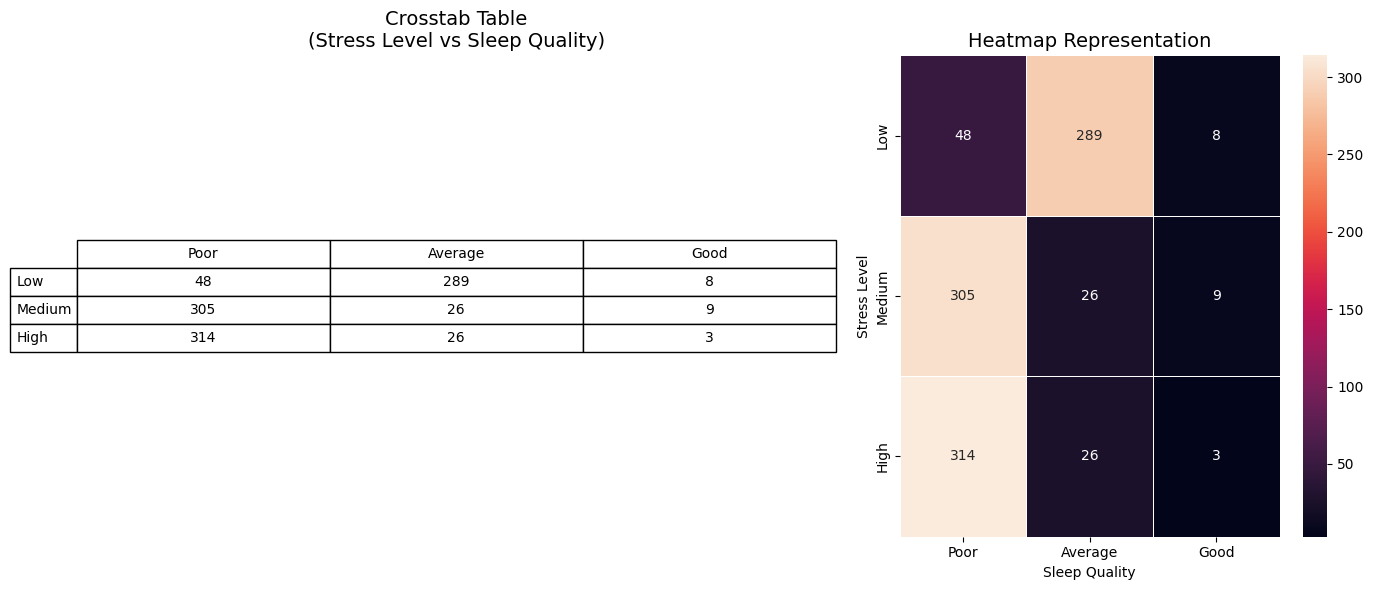

In [11]:
ct = pd.crosstab(df['stress_level'], df['sleep_quality'])
ct = ct.reindex(index=['Low','Medium','High'],
                columns=['Poor','Average','Good'])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.axis('off')
plt.title("Crosstab Table\n(Stress Level vs Sleep Quality)", fontsize=14)

table = plt.table(cellText=ct.values,
                  rowLabels=ct.index,
                  colLabels=ct.columns,
                  loc='center',
                  cellLoc='center')

table.scale(1.6, 1.6)

plt.subplot(1,2,2)
sns.heatmap(ct, annot=True, fmt='d', linewidths=0.5)
plt.title("Heatmap Representation", fontsize=14)
plt.xlabel("Sleep Quality")
plt.ylabel("Stress Level")

plt.tight_layout()
plt.show()

#### “The crosstab shows exact counts, while the heatmap highlights patterns. We can see, Higher stress levels are strongly associated with poor sleep, while lower stress aligns with average sleep

In [12]:
df['mental_health_history'].unique()

array(['1', '0', nan, ' false', ' N', 'FALSE', '1.1', 'Y', ' Yes', 'TRUE',
       'Yes', 'false ', ' Y', 'no', 'yes', ' no'], dtype=object)

#### The Mental Heath column contains inconsistent string values and missing entries, requiring cleaning before further analysis.

## Numerical Distribution (ALL numeric columns)

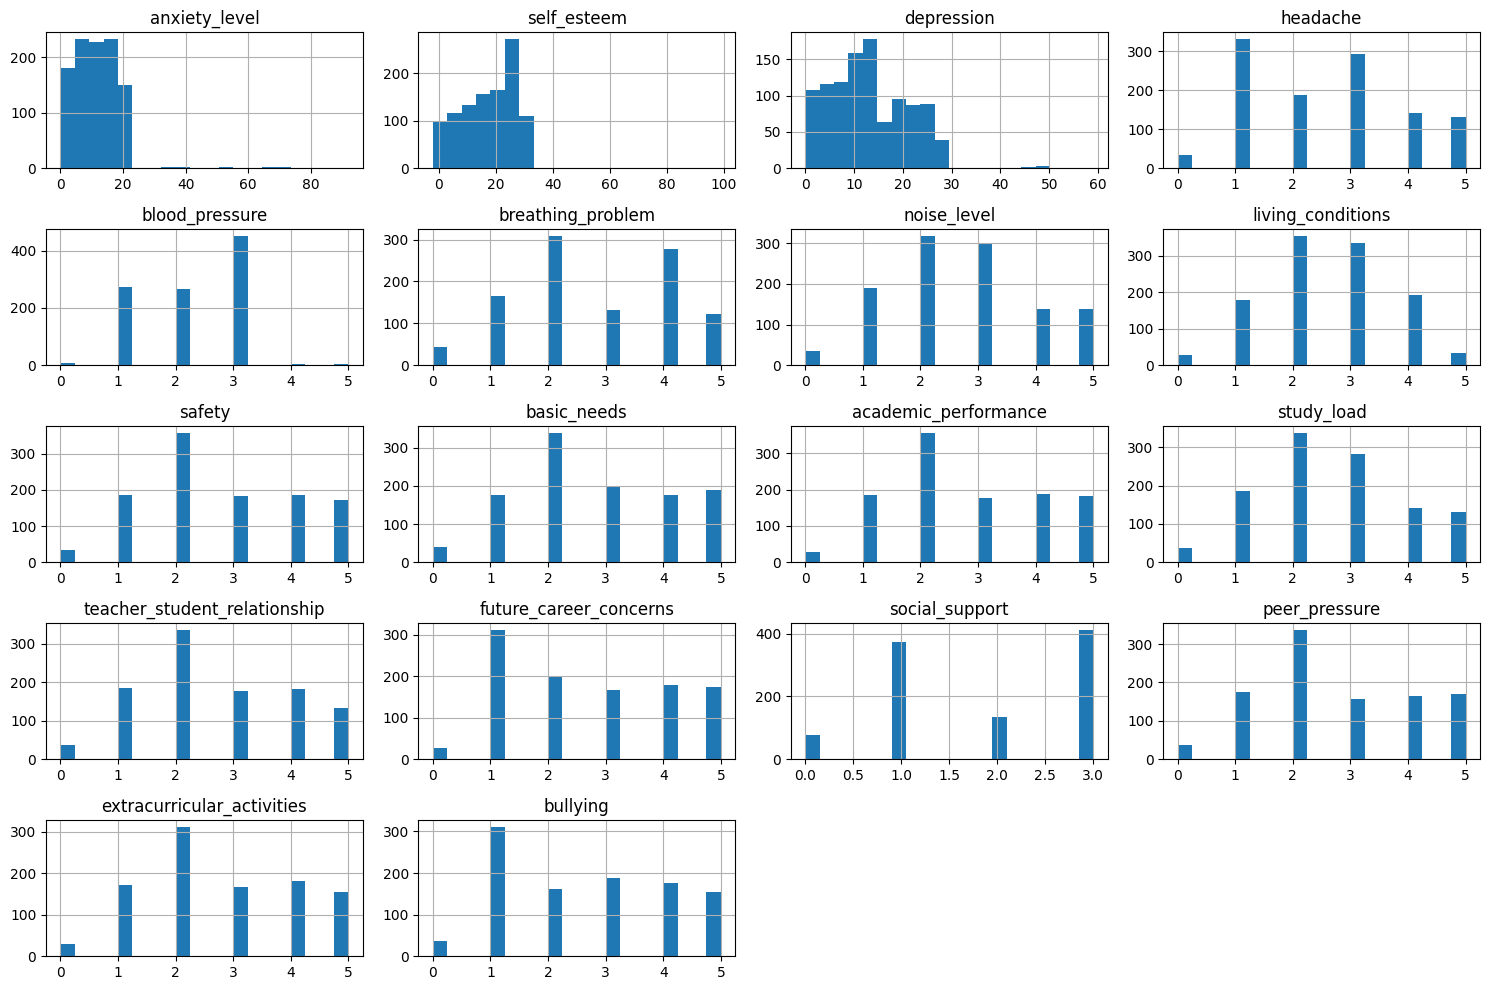

In [13]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

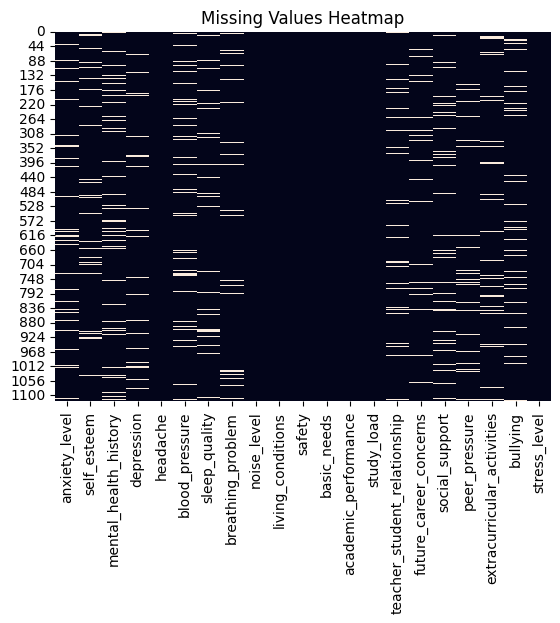

In [14]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Outlier analysis of Numeric Columns 

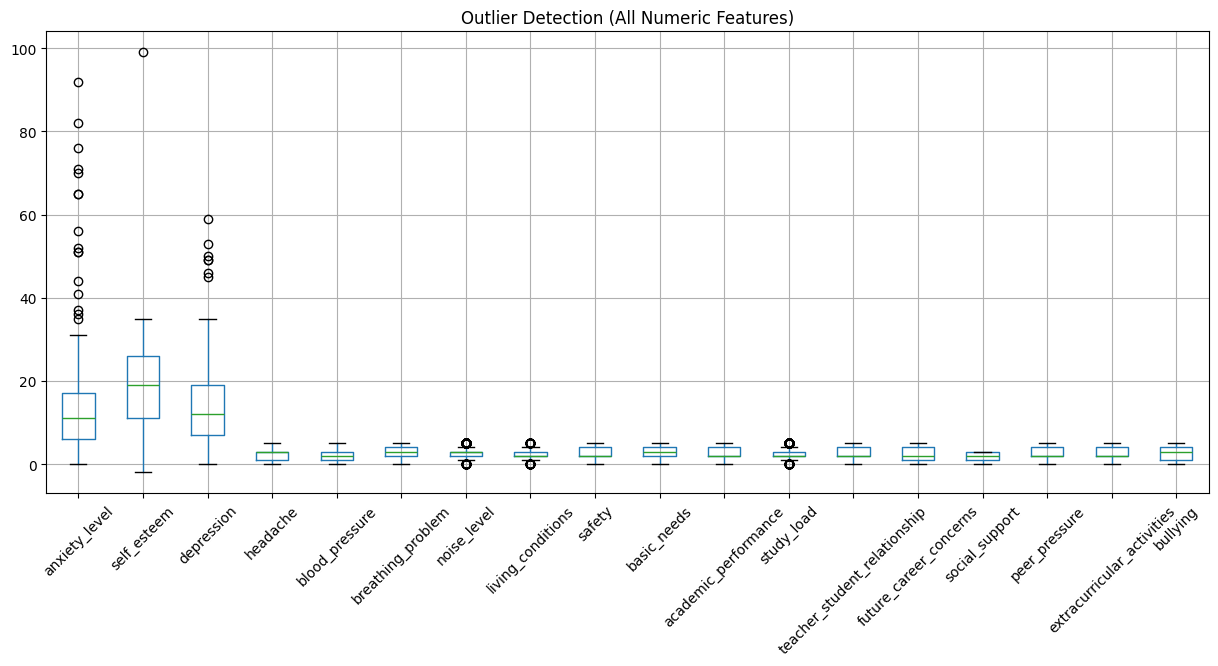

In [15]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

## Correlation (RAW, before cleaning)

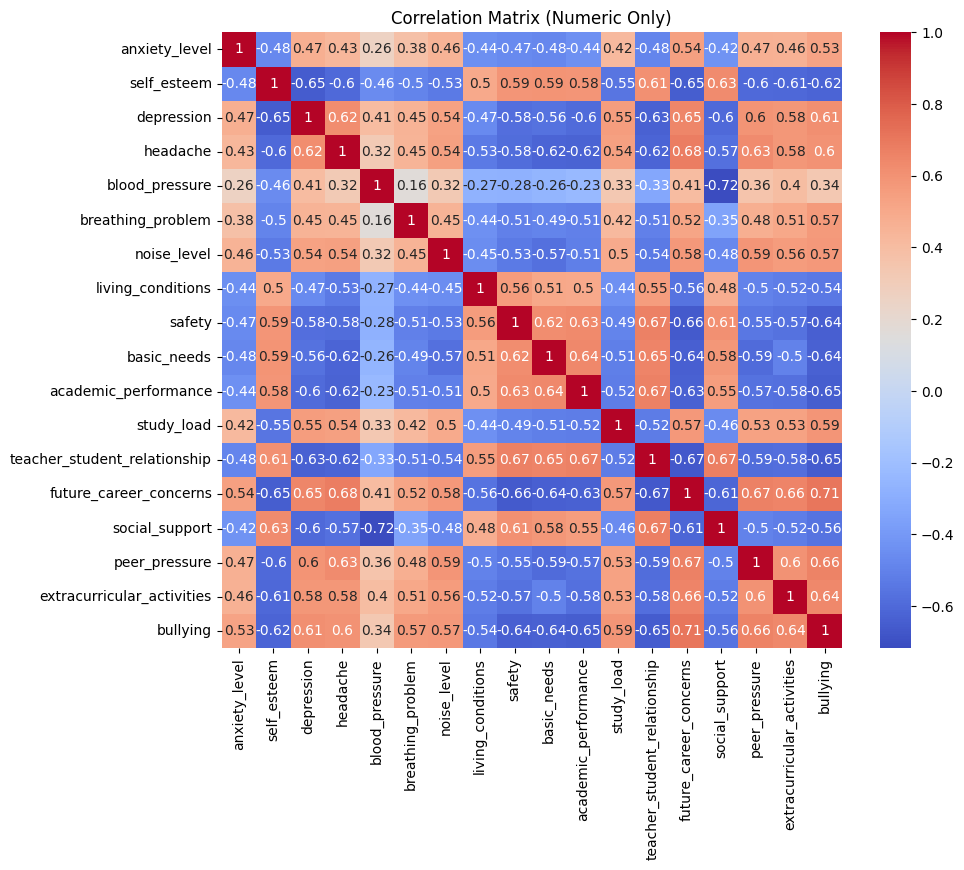

In [16]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix (Numeric Only)")
plt.show()

#### Here, we can observe in the above heatmap that Academic Performance improves with better support and environment ( directly showing positive co-relation ), and decreases with mental stress and negative social factors ( showing negative co-relation ).

## Observing correlation of numeric columns with target column (academic performance)

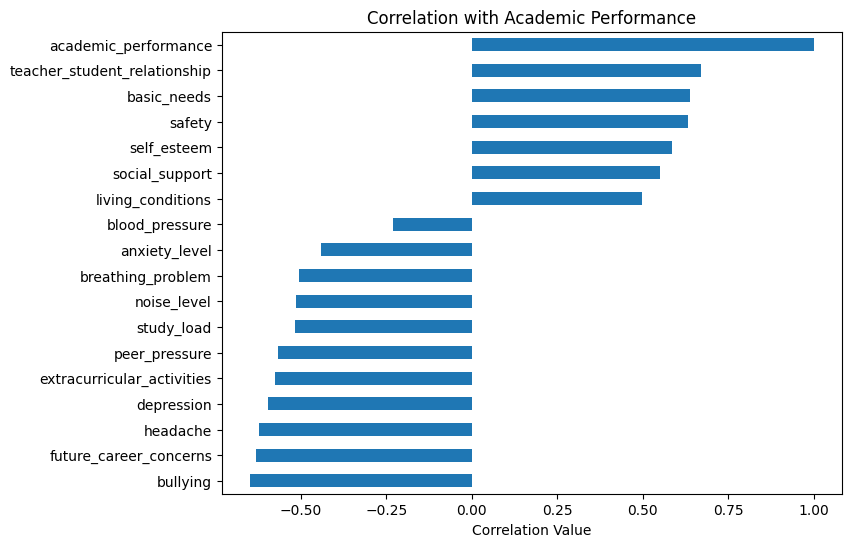

In [17]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_target = numeric_df.corr()['academic_performance'].sort_values()

plt.figure(figsize=(8,6))
corr_target.plot(kind='barh')
plt.title("Correlation with Academic Performance")
plt.xlabel("Correlation Value")
plt.show()

## Data Cleaning

In [18]:

print(df['mental_health_history'].value_counts(dropna=False))
print(df['sleep_quality'].value_counts(dropna=False))
print(df['stress_level'].value_counts(dropna=False))

mental_health_history
0         509
1         488
NaN        98
FALSE       6
 false      4
 Yes        2
TRUE        2
 N          1
Y           1
1.1         1
Yes         1
false       1
 Y          1
no          1
yes         1
 no         1
Name: count, dtype: int64
sleep_quality
Poor       667
Average    341
NaN         90
Good        20
Name: count, dtype: int64
stress_level
Low       375
High      372
Medium    371
Name: count, dtype: int64


#### Checking percentage of missing values in columns

In [19]:
missing_percent = (df.isna().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

social_support                  11.001789
blood_pressure                   9.838998
extracurricular_activities       9.033989
mental_health_history            8.765653
bullying                         8.139535
sleep_quality                    8.050089
peer_pressure                    7.066190
anxiety_level                    7.066190
self_esteem                      6.171735
breathing_problem                5.992844
teacher_student_relationship     5.903399
future_career_concerns           5.098390
depression                       4.919499
headache                         0.000000
academic_performance             0.000000
safety                           0.000000
living_conditions                0.000000
noise_level                      0.000000
basic_needs                      0.000000
study_load                       0.000000
stress_level                     0.000000
dtype: float64


#### Since, the missing value percentage is a lot, imputation will be much affected than dropping them.

### Cleaning Mental_health_history column

In [20]:
df['mental_health_history'].isna().sum()

np.int64(98)

In [21]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()

print(temp.unique())

['1' '0' 'nan' 'false' 'n' '1.1' 'y' 'yes' 'true' 'no']


In [22]:
temp = df['mental_health_history']
temp = temp.str.strip().str.lower()

temp = temp.map({
    '1': 1,
    '0': 0,
    'true': 1,
    'false': 0,
    'yes': 1,
    'no': 0,
    'y': 1,
    'n': 0
})

print("Unmapped:", temp.isna().sum())

temp.fillna(temp.mode()[0], inplace=True)

df['mental_health_history'] = temp.astype(int)

Unmapped: 99


In [23]:
df['mental_health_history'].isna().sum()

np.int64(0)

#### Separating columns on basis of data types

In [24]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

In [25]:
print("Numeric Columns:", numeric_cols.tolist())

Numeric Columns: ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']


In [ ]:
from sklearn.impute import SimpleImputer

continuous_cols = [
    'anxiety_level','self_esteem','depression'
]

ordinal_cols = [
    'headache','blood_pressure','breathing_problem','noise_level',
    'living_conditions','safety','basic_needs','academic_performance',
    'study_load','teacher_student_relationship','future_career_concerns',
    'social_support','peer_pressure','extracurricular_activities','bullying'
]

categorical_cols = [
    'mental_health_history','sleep_quality','stress_level'
]

for col in df.columns:
    
    before = df[col].isnull().sum()
    
    if col in continuous_cols:
        if abs(df[col].skew()) > 0.5:
            strategy = 'median'
            fill_value = df[col].median()
        else:
            strategy = 'mean'
            fill_value = df[col].mean()
    elif col in ordinal_cols or col in categorical_cols:
        strategy = 'most_frequent'
        fill_value = df[col].mode()[0]
    else:
        strategy = 'unknown'
        fill_value = None

    if before > 0:
        imputer = SimpleImputer(strategy=strategy)
        df[[col]] = imputer.fit_transform(df[[col]])
    
    after = df[col].isnull().sum()
    

In [27]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,Good,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,2.0,5.0,4.0,High
1,6.0,26.0,0,8.0,1,2.0,Average,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,2.0,1.0,Low
2,5.0,25.0,0,6.0,1,2.0,Average,1.0,2,4,...,4,4.0,2,2.0,1.0,3.0,2.0,1.0,1.0,Low
3,12.0,23.0,1,10.0,3,1.0,Poor,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,2.0,3.0,3.0,Medium
4,19.0,15.0,1,27.0,5,3.0,Poor,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,13.0,23.0,0,12.0,3,1.0,Poor,2.0,3,3,...,3,2.0,3,2.0,2.0,3.0,2.0,3.0,2.0,Medium
1114,7.0,22.0,0,1.0,5,3.0,Average,3.0,5,5,...,2,2.0,5,3.0,4.0,3.0,1.0,4.0,4.0,High
1115,13.0,20.0,0,9.0,2,1.0,Poor,4.0,3,3,...,2,3.0,2,3.0,2.0,3.0,3.0,3.0,1.0,Medium
1116,16.0,12.0,1,22.0,4,3.0,Poor,4.0,3,1,...,2,2.0,5,2.0,5.0,1.0,2.0,5.0,5.0,High


### Post-Clean EDA Analysis

In [28]:
df.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1118 non-null   float64
 1   self_esteem                   1118 non-null   float64
 2   mental_health_history         1118 non-null   int64  
 3   depression                    1118 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1118 non-null   float64
 6   sleep_quality                 1118 non-null   object 
 7   breathing_problem             1118 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  stu

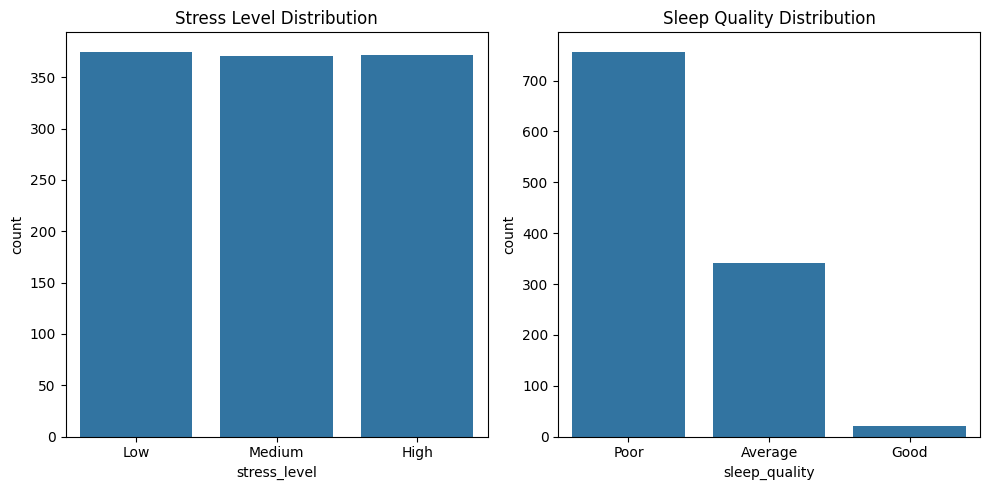

In [30]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(x='stress_level', data=df, order=['Low','Medium','High'])
plt.title("Stress Level Distribution")

plt.subplot(1,2,2)
sns.countplot(x='sleep_quality', data=df, order=['Poor','Average','Good'])
plt.title("Sleep Quality Distribution")

plt.tight_layout()
plt.show()

#### After cleaning, stress_level remained unchanged as it was already consistent, whereas sleep_quality showed an increase in the ‘Poor’ category due to imputation of missing values using mode. Also, conversion of these categorical columns to numerical will take pace in encoding after train_test_split in order to avoid data leakage

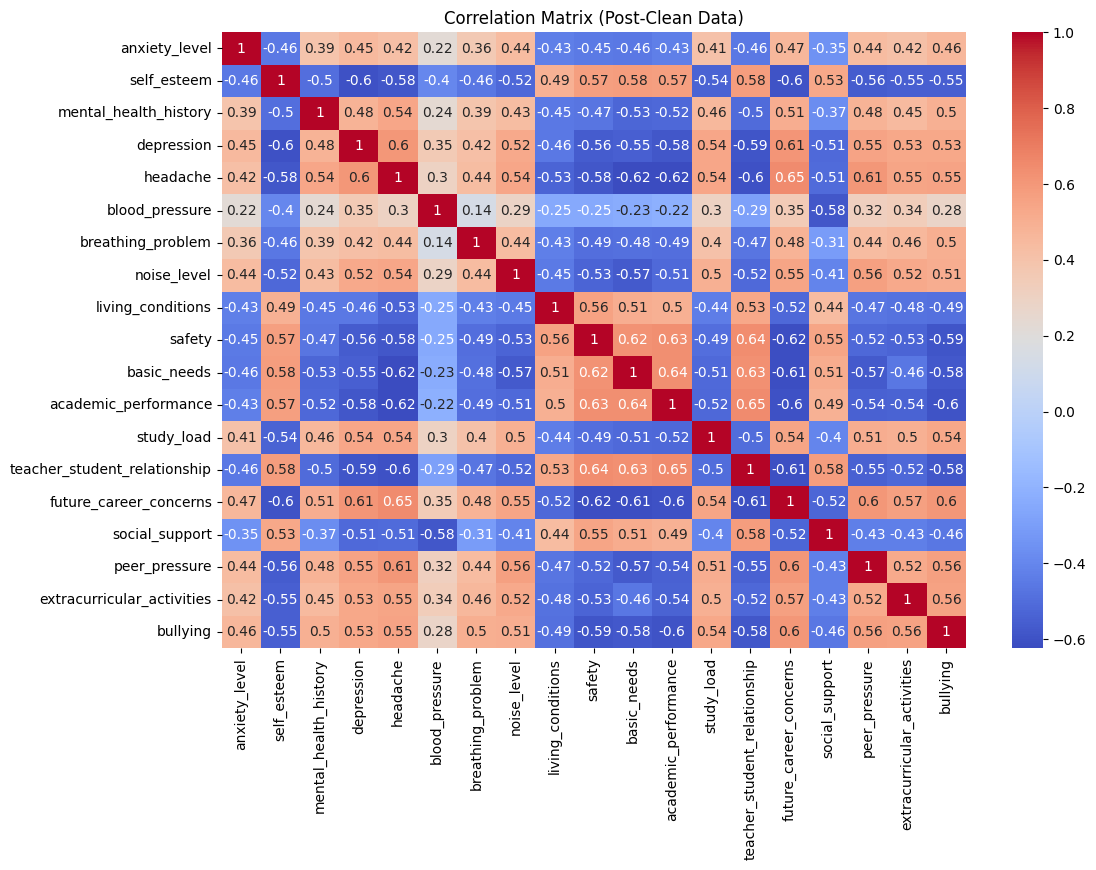

In [31]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)

plt.title("Correlation Matrix (Post-Clean Data)")
plt.show()

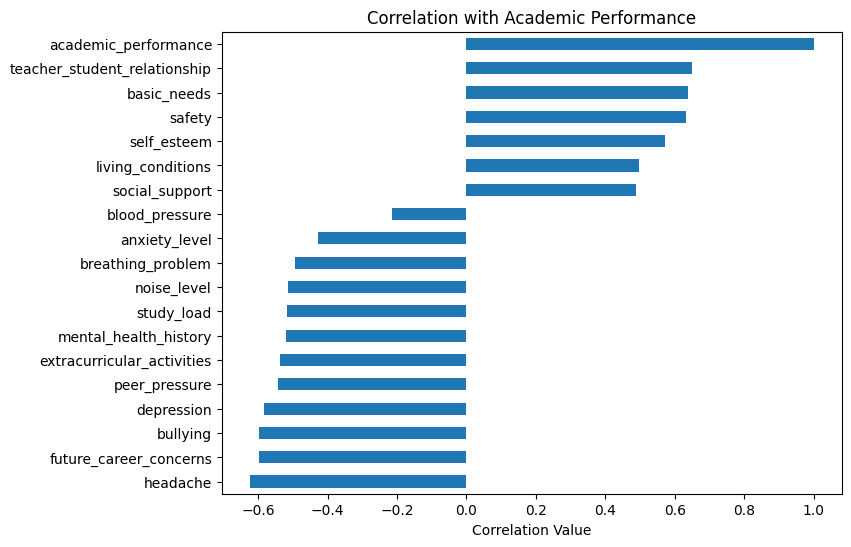

In [32]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_target = numeric_df.corr()['academic_performance'].sort_values()

plt.figure(figsize=(8,6))
corr_target.plot(kind='barh')
plt.title("Correlation with Academic Performance")
plt.xlabel("Correlation Value")
plt.show()

## Encoding

In [33]:
from sklearn.preprocessing import OrdinalEncoder 

In [34]:
df.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [35]:
categorical_cols = df.select_dtypes(include=['object']).columns
encoder = OrdinalEncoder(categories=[['Poor','Average','Good'],   ['Low','Medium','High']])

df[categorical_cols] = encoder.fit_transform(df[['sleep_quality','stress_level']])
df[categorical_cols] = df[categorical_cols].astype(int)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1118 non-null   float64
 1   self_esteem                   1118 non-null   float64
 2   mental_health_history         1118 non-null   int64  
 3   depression                    1118 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1118 non-null   float64
 6   sleep_quality                 1118 non-null   int64  
 7   breathing_problem             1118 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  stu

In [37]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,2,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,2.0,5.0,4.0,2
1,6.0,26.0,0,8.0,1,2.0,1,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,2.0,1.0,0
2,5.0,25.0,0,6.0,1,2.0,1,1.0,2,4,...,4,4.0,2,2.0,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1,10.0,3,1.0,0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,2.0,3.0,3.0,1
4,19.0,15.0,1,27.0,5,3.0,0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2


## Relationship Of Stress Level, Sleep Quality with Academic Performance

After encoding the categorical variables into numerical values, we analyzed the relationship between **stress level**, **sleep quality**, and **academic performance**.

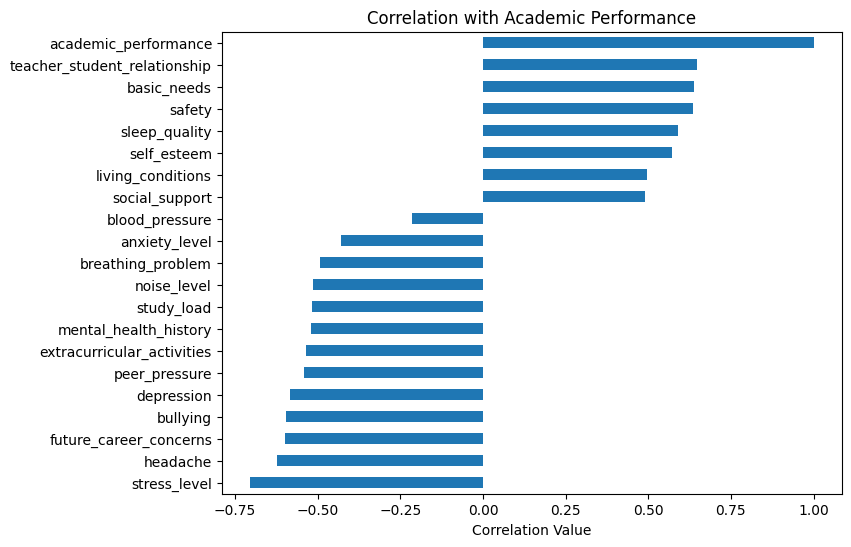

In [38]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_target = numeric_df.corr()['academic_performance'].sort_values()

plt.figure(figsize=(8,6))
corr_target.plot(kind='barh')
plt.title("Correlation with Academic Performance")
plt.xlabel("Correlation Value")
plt.show()

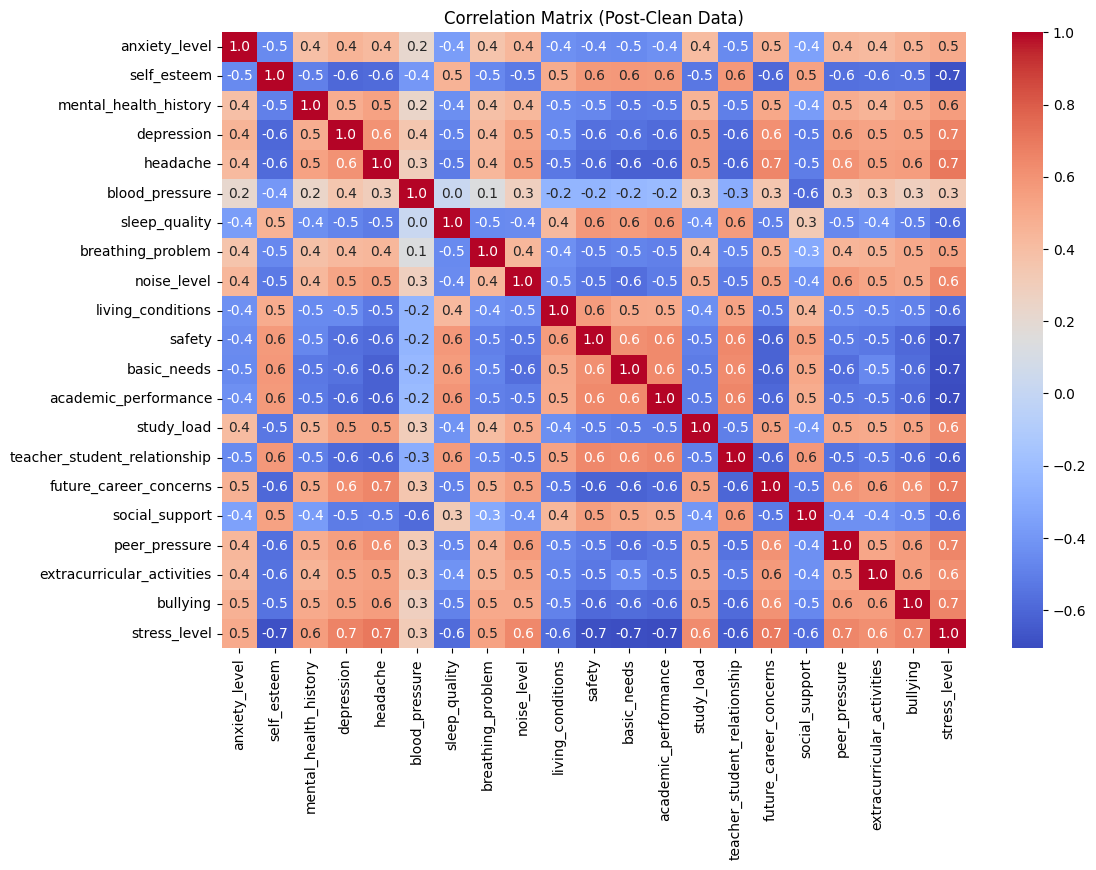

In [39]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt=".1f")
plt.title("Correlation Matrix (Post-Clean Data)")
plt.show()

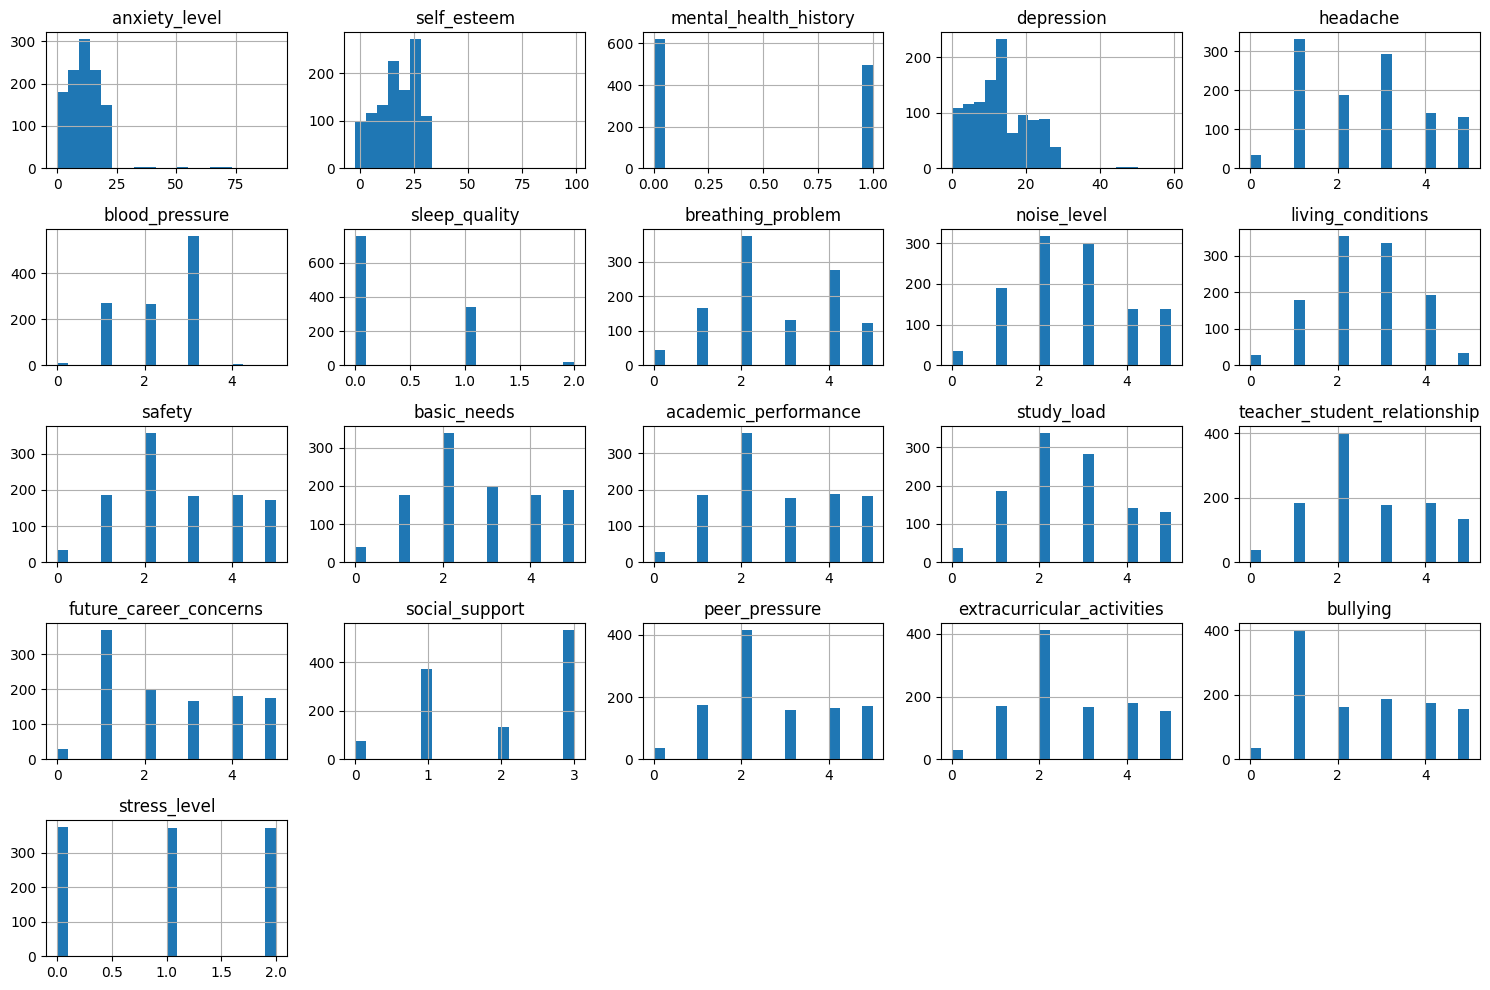

In [40]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

# Outlier detection and Removal

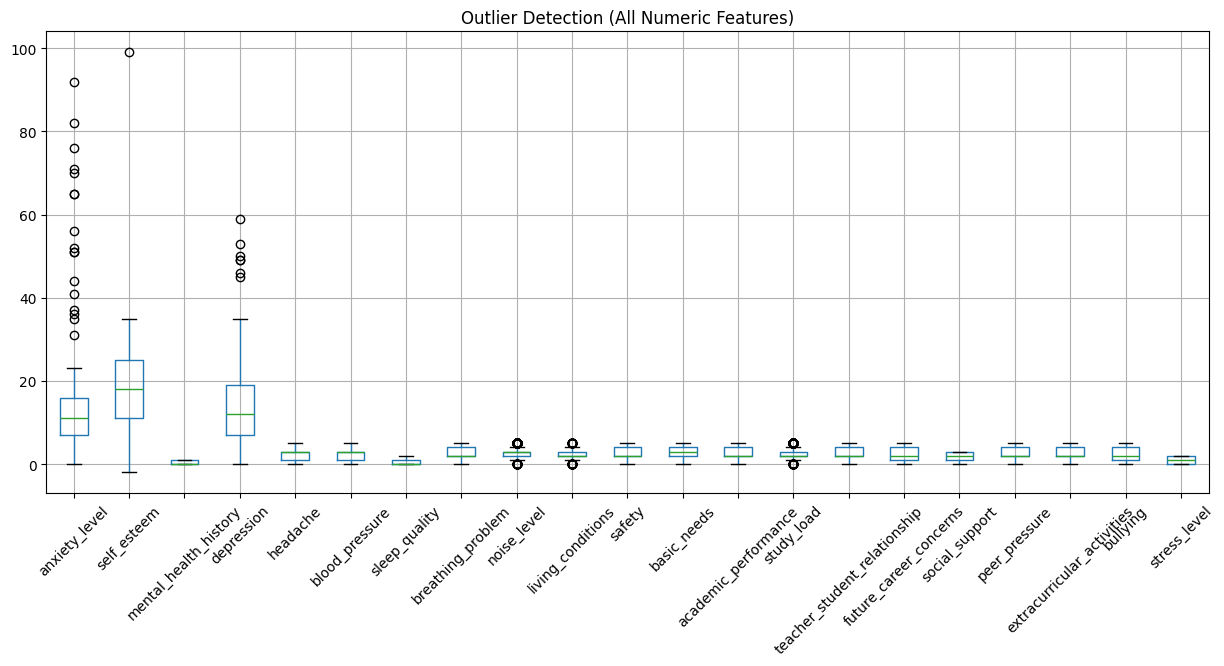

In [41]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

## Outlier Removal


In [42]:
def remove_outliers_iqr(df, columns, iqr_multiplier=1.5):
    """Remove outliers using standard IQR method (multiplier=1.5 is the convention)"""
    initial_len = len(df)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    final_len = len(df)
    removed_count = initial_len - final_len
    print(f"Initial rows: {initial_len}")
    print(f"Final rows: {final_len}")
    print(f"Rows removed: {removed_count} ({100*removed_count/initial_len:.2f}%)")
    return df

numeric_cols_for_outlier = df.select_dtypes(include=['int64','float64']).columns.tolist()
df_cleaned = remove_outliers_iqr(df.copy(), numeric_cols_for_outlier, iqr_multiplier=1.5)


Initial rows: 1118
Final rows: 655
Rows removed: 463 (41.41%)


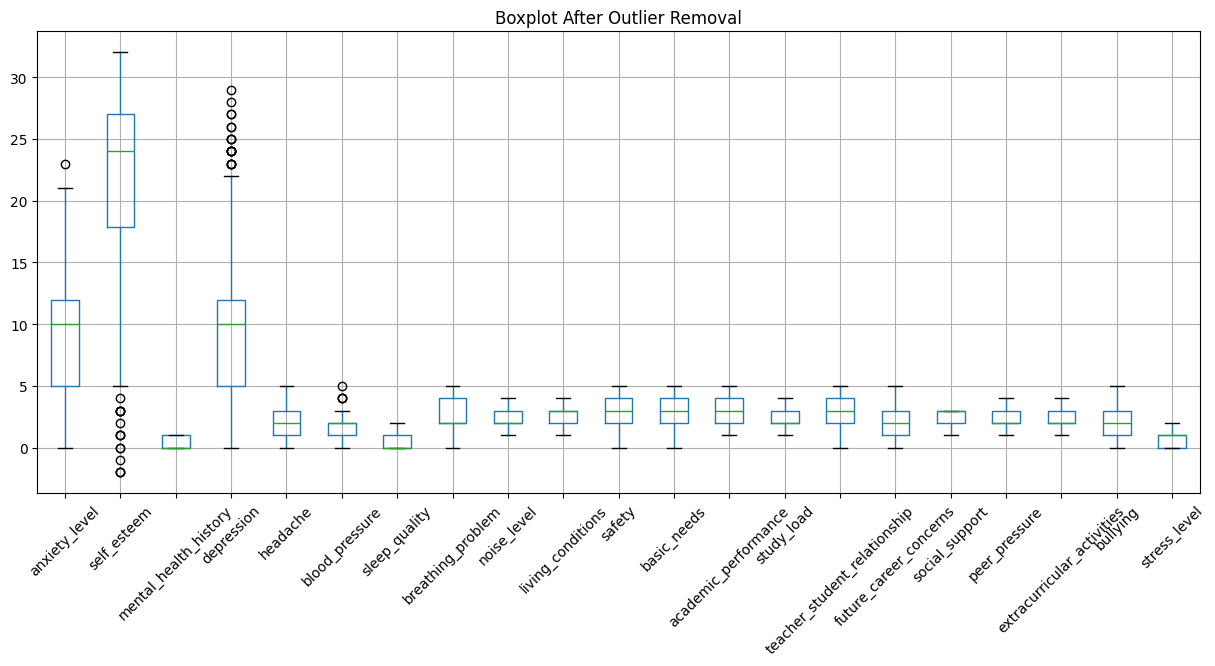

In [43]:
numeric_df_cleaned = df_cleaned.select_dtypes(include=['int64','float64'])

numeric_df_cleaned.boxplot(figsize=(15,6))
plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=45)
plt.show()


## Train_Test_Split with Scaling

In [44]:
X = df_cleaned.drop(columns=['academic_performance'])
y = df_cleaned['academic_performance']

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Fix: Fit scaler on X_train only, transform X_test (no leakage) ──
from sklearn.preprocessing import RobustScaler
scale_cols = ['anxiety_level', 'self_esteem', 'depression']
scaler = RobustScaler()

X_train = X_train.copy()
X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# ── GradientBoostingRegressor ──
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('=== GradientBoostingRegressor ===')
print('Train R2 :', r2_score(y_train, train_pred))
print('Test  R2 :', r2_score(y_test, y_pred))
print('MSE      :', mean_squared_error(y_test, y_pred))
print('MAE      :', mean_absolute_error(y_test, y_pred))


=== GradientBoostingRegressor ===
Train R2 : 0.8096046284816751
Test  R2 : 0.8271149412681955
MSE      : 0.25995723183471137
MAE      : 0.5055231476161214
